# 01 · EDA de Flujo de Órdenes y Volatilidad — Binance Real

Análisis exploratorio sobre trades reales de Binance (BTCUSDT/ETHUSDT) y comparación de modelos
de forecasting de volatilidad realizada. Para que el notebook corra rápido, la sección de EDA usa
un solo día real (no los 24.8M de trades completos); los resultados de modelos son los de la
corrida completa de `python -m src.pipeline`.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import pandas as pd
import numpy as np

from src.ingest import COLUMNS, bucket_trades
from src.features import compute_bucket_features

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


## 1. Un día real de trades BTCUSDT

In [2]:
one_day = pl.read_csv("data/raw_btc/BTCUSDT-aggTrades-2026-08-25.csv", has_header=False, new_columns=COLUMNS)
one_day = one_day.with_columns(
    (pl.col("timestamp_us") // 1_000).alias("timestamp_ms"),
    pl.lit("2026-08-25").alias("day"),
    pl.lit("BTCUSDT").alias("symbol"),
)
print(f"{one_day.height:,} trades reales en un solo dia")
one_day.head()


1,620,679 trades reales en un solo dia


agg_trade_id,price,quantity,first_trade_id,last_trade_id,timestamp_us,is_buyer_maker,is_best_match,timestamp_ms,day,symbol
i64,f64,f64,i64,i64,i64,bool,bool,i64,str,str
4043645753,78992.76,0.001,6613400128,6613400128,1787616000207591,false,true,1787616000207,"""2026-08-25""","""BTCUSDT"""
4043645754,78992.75,0.00491,6613400129,6613400149,1787616000223197,true,true,1787616000223,"""2026-08-25""","""BTCUSDT"""
4043645755,78992.74,0.0002,6613400150,6613400151,1787616000223197,true,true,1787616000223,"""2026-08-25""","""BTCUSDT"""
4043645756,78992.73,0.00013,6613400152,6613400152,1787616000223197,true,true,1787616000223,"""2026-08-25""","""BTCUSDT"""
4043645757,78992.49,0.00021,6613400153,6613400155,1787616000223197,true,true,1787616000223,"""2026-08-25""","""BTCUSDT"""


In [3]:
bucketed = bucket_trades(one_day)
features = compute_bucket_features(bucketed).to_pandas()
print(f"{len(features)} buckets de 30s")
features.head()


2879 buckets de 30s

,symbol,day,bucket_start_ms,open_price,close_price,high_price,low_price,dollar_volume,total_volume,n_trades,taker_buy_volume,taker_sell_volume,vwap,order_flow_imbalance,price_range_pct,bucket_return,realized_volatility,target_next_realized_volatility
0,BTCUSDT,2026-08-25,1787616000000,78992.76,79002.20,79004.01,78968.49,6.149846e+06,77.85530,1100,12.91487,64.94043,78990.720255,-0.668234,4.496615e-04,1.195046e-04,1.145725e-04,1.212858e-04
1,BTCUSDT,2026-08-25,1787616030000,79002.19,78964.00,79004.02,78945.14,9.411242e+05,11.91504,517,4.03990,7.87514,78986.235878,-0.321882,7.452958e-04,-4.834043e-04,1.212858e-04,1.014320e-04
2,BTCUSDT,2026-08-25,1787616060000,78964.00,78950.01,78991.99,78950.00,2.025374e+05,2.56453,529,1.02337,1.54116,78976.404801,-0.201904,5.317613e-04,-1.771693e-04,1.014320e-04,6.333122e-07
3,BTCUSDT,2026-08-25,1787616090000,78950.00,78950.01,78950.01,78950.00,2.800712e+05,3.54745,61,2.43140,1.11605,78950.006854,0.370787,1.266624e-07,1.266624e-07,6.333122e-07,4.496312e-05
4,BTCUSDT,2026-08-25,1787616120000,78950.00,78961.99,78966.00,78950.00,8.592908e+04,1.08829,193,0.97937,0.10892,78957.885671,0.799833,2.026599e-04,1.518683e-04,4.496312e-05,4.787375e-05


## 2. Precio (VWAP) y volatilidad realizada a lo largo del día

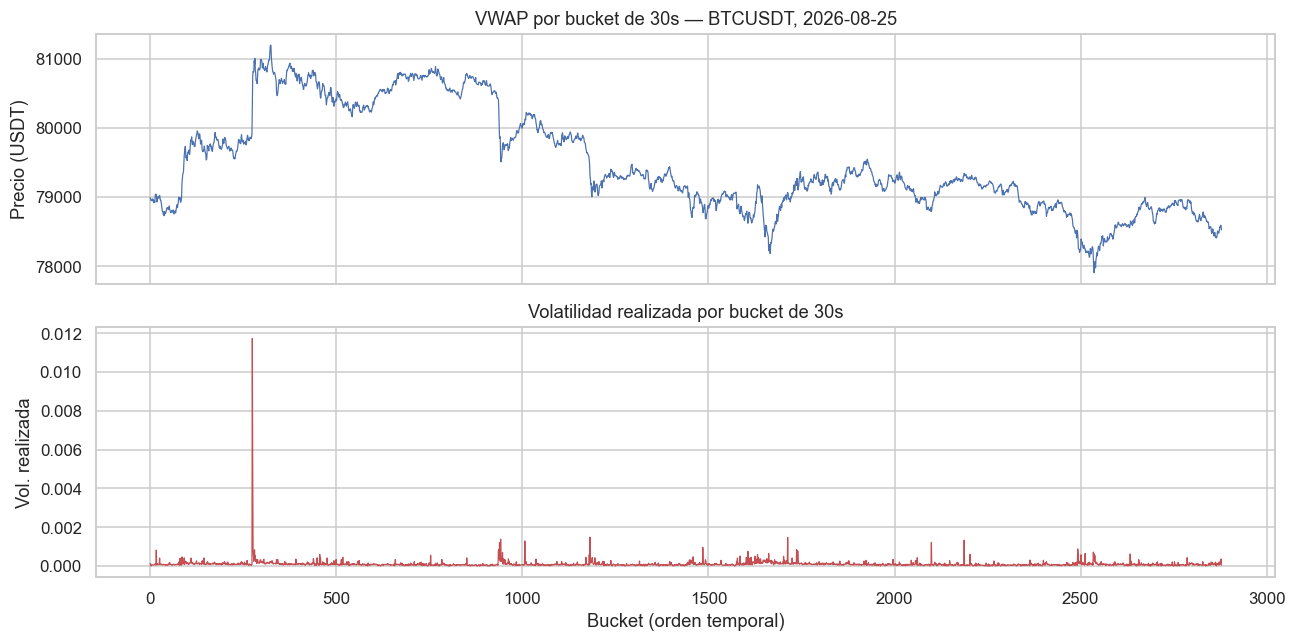

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(features["vwap"].to_numpy(), color="#4C72B0", linewidth=0.8)
axes[0].set_title("VWAP por bucket de 30s — BTCUSDT, 2026-08-25")
axes[0].set_ylabel("Precio (USDT)")

axes[1].plot(features["realized_volatility"].to_numpy(), color="#C44E52", linewidth=0.8)
axes[1].set_title("Volatilidad realizada por bucket de 30s")
axes[1].set_ylabel("Vol. realizada")
axes[1].set_xlabel("Bucket (orden temporal)")
plt.tight_layout()
plt.savefig("outputs/reports/price_and_volatility.png", dpi=150)
plt.show()


## 3. Desbalance de flujo de órdenes vs. volatilidad futura

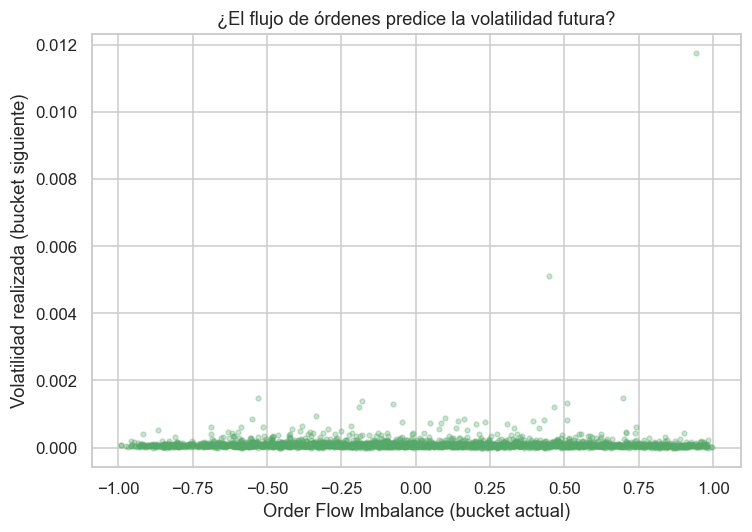

Correlacion: 0.023366913438905446


In [5]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(features["order_flow_imbalance"], features["target_next_realized_volatility"], alpha=0.3, s=10, color="#55A868")
ax.set_xlabel("Order Flow Imbalance (bucket actual)")
ax.set_ylabel("Volatilidad realizada (bucket siguiente)")
ax.set_title("¿El flujo de órdenes predice la volatilidad futura?")
plt.tight_layout()
plt.savefig("outputs/reports/ofi_vs_future_vol.png", dpi=150)
plt.show()
print("Correlacion:", features["order_flow_imbalance"].corr(features["target_next_realized_volatility"]))


## 4. Resultados reales (corrida completa: 24.8M trades, 5-fold GroupKFold por día)

In [6]:
metrics = pd.read_csv("outputs/reports/model_metrics.csv")
metrics


,model,rmspe_mean,rmspe_std
0,historical_baseline,4.578870,1.211857
1,lightgbm,5.559281,1.789662
2,pytorch_mlp_embeddings,9.536274,3.370676


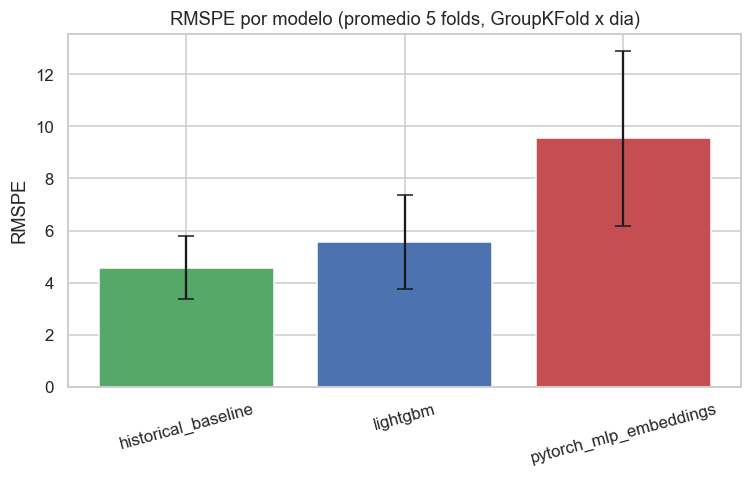

In [7]:
fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(metrics["model"], metrics["rmspe_mean"], yerr=metrics["rmspe_std"], capsize=5,
               color=["#55A868","#4C72B0","#C44E52"])
ax.set_title("RMSPE por modelo (promedio 5 folds, GroupKFold x dia)")
ax.set_ylabel("RMSPE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("outputs/reports/rmspe_comparison.png", dpi=150)
plt.show()


## 5. Conclusión

- Hallazgo honesto, no forzado: el baseline de persistencia (RMSPE 4.58) le gana a LightGBM (5.56)
  y a la MLP con embeddings (9.54) en el horizonte de 30 segundos — consistente con la literatura
  de volatilidad de altísima frecuencia, donde el clustering de volatilidad hace que "lo que
  acaba de pasar" sea un baseline genuinamente difícil de superar.
- El scatter de OFI vs. volatilidad futura no muestra una relación lineal fuerte a este horizonte —
  coherente con por qué los modelos más complejos no logran superar al baseline aquí.